Notebook Overview

This is a 4th attempt to see if data Augementation Improves Models ability to classify images. On this Epoch i will use two models, one where the data has been augmented and a non-augmented  and compare which accuracy is better. Ill be using 50 epochs for each Process and also same number of batches. In this attempt ill add more complexity to the augmented model. Since its taking the harder test with images translated differently. Ill also be making the translations less aggressive to avoid distorting the image pixels

# Test 1
Non-Augmenteted data Model on 50 epochs and steps_per epoch of 1000 meaning batch_size will be 50

In [11]:
import tensorflow as tf

In [12]:
#Loading Cifar dataset
(train_images,train_labels),(test_images,test_labels)=tf.keras.datasets.cifar10.load_data()

In [13]:
#Normalize Dataset
train_images,test_images  = train_images/255.0,test_images/255.0

In [14]:
train_images.shape

(50000, 32, 32, 3)

In [15]:
# Defining shape of input data
shape = train_images[0].shape
print(shape)

(32, 32, 3)


In [16]:
#Building Model
layers = tf.keras.layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(64,(3,3),activation='relu',input_shape= shape))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,(3,3),activation ='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64,activation = 'relu'))
model.add(layers.Dense(10,activation = 'softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,898 (554.29 KB)

 Trainable params: 141,898 (554.29 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# compiling model
model.compile(optimizer= 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [18]:
training_model = model.fit(train_images,train_labels,epochs =50,steps_per_epoch= 1000,validation_data=(test_images,test_labels))

Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 72s 71ms/step - accuracy: 0.3370 - loss: 1.8030 - val_accuracy: 0.5296 - val_loss: 1.3070
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 73s 73ms/step - accuracy: 0.5574 - loss: 1.2411 - val_accuracy: 0.5965 - val_loss: 1.1327
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 70s 70ms/step - accuracy: 0.6213 - loss: 1.0766 - val_accuracy: 0.6321 - val_loss: 1.0458
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 70s 70ms/step - accuracy: 0.6634 - loss: 0.9630 - val_accuracy: 0.6682 - val_loss: 0.9558
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 84s 72ms/step - accuracy: 0.6865 - loss: 0.8875 - val_accuracy: 0.6523 - val_loss: 1.0289
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.7138 - loss: 0.8206 - val_accuracy: 0.6915 - val_loss: 0.8900
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 79s 69ms/step - accuracy: 0.7351 - loss: 0.7609 - val_accuracy: 0.7008 - val_loss: 0.8612
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 69s 69ms/step - accuracy: 0.7497 -

In [19]:
model.evaluate(test_images,test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6837 - loss: 2.1723


[2.1932051181793213, 0.6830999851226807]

In [22]:
import os
import shutil
from google.colab import drive

# Attempt to unmount if already mounted
if os.path.ismount('/content/drive'):
    drive.flush_and_unmount()

# Remove all files and subdirectories from /content/drive if it exists
if os.path.exists('/content/drive'):
    shutil.rmtree('/content/drive')

# Recreate the empty directory /content/drive
os.makedirs('/content/drive')

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [23]:
# Saving History and model stats
import os
save_path = '/content/drive/MyDrive/ML_Project_2' #creating project folder in drive
if not os.path.exists(save_path):
    os.makedirs(save_path)
model.save(f'{save_path}/my_trained_model1.keras')
import pandas as pd
hist_df = pd.DataFrame(training_model.history)
hist_df.to_csv(f'{save_path}/training_log1.csv', index=False)


# Test 2
Augmented data model running on 50 epochs and batch size of 1000

In [35]:
import tensorflow as tf

In [36]:
#Loading Cifar dataset
(train_images,train_labels),(test_images,test_labels)=tf.keras.datasets.cifar10.load_data()

In [37]:
# Normalizing Data
train_images,test_images  = train_images/255.0,test_images/255.0

In [38]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator


datagen = ImageDataGenerator(rotation_range=15, # images will be randomly rotated by a degree of 40
width_shift_range=0.1,# Images will be randomly shifted horizontally by up to 20% of their total width.
height_shift_range=0.1,#img randomly shifted vertically
shear_range=0.1,# Images will be randomly sheared (tilted along an axis) by up to 20 degrees.
zoom_range=0.1, #Images will be randomly zoomed in by up to 20%
horizontal_flip=True, # randomly flipped
fill_mode='nearest')
'''
When transformations cause pixels to go outside the image boundaries (e.g., rotation, shift),
this specifies how to fill the newly created empty pixels (here, it fills them with the nearest pixel value).
'''




'\nWhen transformations cause pixels to go outside the image boundaries (e.g., rotation, shift),\nthis specifies how to fill the newly created empty pixels (here, it fills them with the nearest pixel value).\n'

In [39]:
# Defining shape of input data
shape = train_images[0].shape
print(shape)

(32, 32, 3)


In [40]:
#Building Augmented Model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


model_optimized = Sequential()
model_optimized.add(Conv2D(64, (3, 3), activation='relu', input_shape=shape))
model_optimized.add(MaxPooling2D((2, 2)))
model_optimized.add(Conv2D(128, (3, 3), activation='relu')) # Increased filters
model_optimized.add(MaxPooling2D((2, 2)))
model_optimized.add(Conv2D(128, (3, 3), activation='relu')) # Increased filters
model_optimized.add(Flatten())
model_optimized.add(Dense(128, activation='relu')) # Increased neurons
model_optimized.add(Dense(10, activation='softmax'))

model_optimized.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,794 (1.86 MB)

 Trainable params: 486,794 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
'''
This iterator will be responsible for:
Taking the train_images and train_labels.
Dividing them into batches of 50 images (as specified by batch_size=50).
Applying the random data augmentations (rotations, shifts, flips, brightness changes, etc.) that you configured in your datagen object to each image within those batches.
Yielding (providing) these augmented batches of images and their corresponding labels whenever requested by the training loop.
'''
train_generator = datagen.flow(train_images,train_labels,batch_size =50)

In [42]:
#compiling model
model_optimized.compile(optimizer= 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [43]:
augmented_training_model= model_optimized.fit(train_generator,epochs = 75,steps_per_epoch= 1000,validation_data=(test_images,test_labels))

Epoch 1/75
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 139s 137ms/step - accuracy: 0.3266 - loss: 1.8184 - val_accuracy: 0.5324 - val_loss: 1.2811
Epoch 2/75
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 134s 134ms/step - accuracy: 0.5251 - loss: 1.3114 - val_accuracy: 0.5780 - val_loss: 1.1730
Epoch 3/75
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 134s 134ms/step - accuracy: 0.5872 - loss: 1.1624 - val_accuracy: 0.6597 - val_loss: 0.9671
Epoch 4/75
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 134s 134ms/step - accuracy: 0.6248 - loss: 1.0631 - val_accuracy: 0.6607 - val_loss: 0.9639
Epoch 5/75
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 137s 137ms/step - accuracy: 0.6469 - loss: 0.9953 - val_accuracy: 0.6895 - val_loss: 0.8744
Epoch 6/75
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 143s 138ms/step - accuracy: 0.6778 - loss: 0.9258 - val_accuracy: 0.7160 - val_loss: 0.8154
Epoch 7/75
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 133s 133ms/step - accuracy: 0.6877 - loss: 0.8914 - val_accuracy: 0.7117 - val_loss: 0.8363
Epoch 8/75
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 135s 135ms/step - ac

In [45]:
model_optimized.evaluate(test_images,test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8061 - loss: 0.6196


[0.624038577079773, 0.8025000095367432]

In [44]:
# Saving History and model stats
import os
save_path = '/content/drive/MyDrive/ML_Project_2' #creating project folder in drive
if not os.path.exists(save_path):
    os.makedirs(save_path)
model_optimized.save(f'{save_path}/aug2_trained_model.keras')
import pandas as pd
hist_df = pd.DataFrame(augmented_training_model.history)
hist_df.to_csv(f'{save_path}/aug2_training_log.csv', index=False)


# Visualizing Model's perfomance

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
non_aug_history_path ='/content/drive/MyDrive/ML_Project_2/training_log1.csv'
aug_history_path = '/content/drive/MyDrive/ML_Project_2/aug2_training_log.csv'

In [13]:
#Loading to pandas dataframe
import pandas as pd
non_aug_history = pd.read_csv(non_aug_history_path)
aug_history = pd.read_csv(aug_history_path)


In [20]:
aug_history.tail()

,accuracy,loss,val_accuracy,val_loss
70,0.83082,0.483642,0.8103,0.589813
71,0.83276,0.477180,0.8033,0.634979
72,0.83452,0.475850,0.8074,0.594750
73,0.83174,0.480891,0.8094,0.588052
74,0.83480,0.470857,0.8025,0.624039


In [17]:
non_aug_history.tail()

,accuracy,loss,val_accuracy,val_loss
45,0.94336,0.157030,0.6876,2.060644
46,0.94334,0.156670,0.6821,2.101708
47,0.94668,0.149481,0.6813,2.226925
48,0.94690,0.148473,0.6839,2.350437
49,0.94850,0.144748,0.6831,2.193205


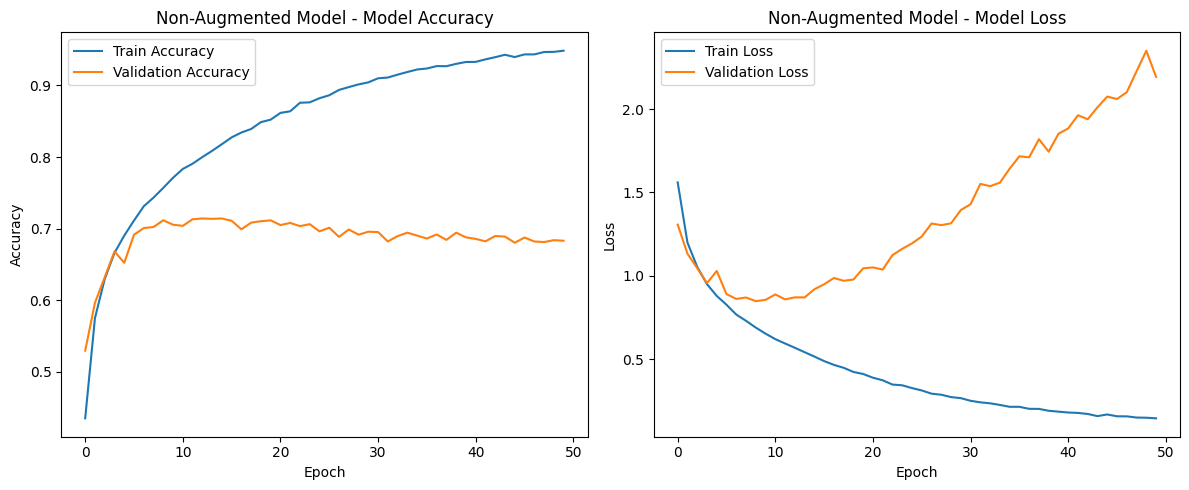

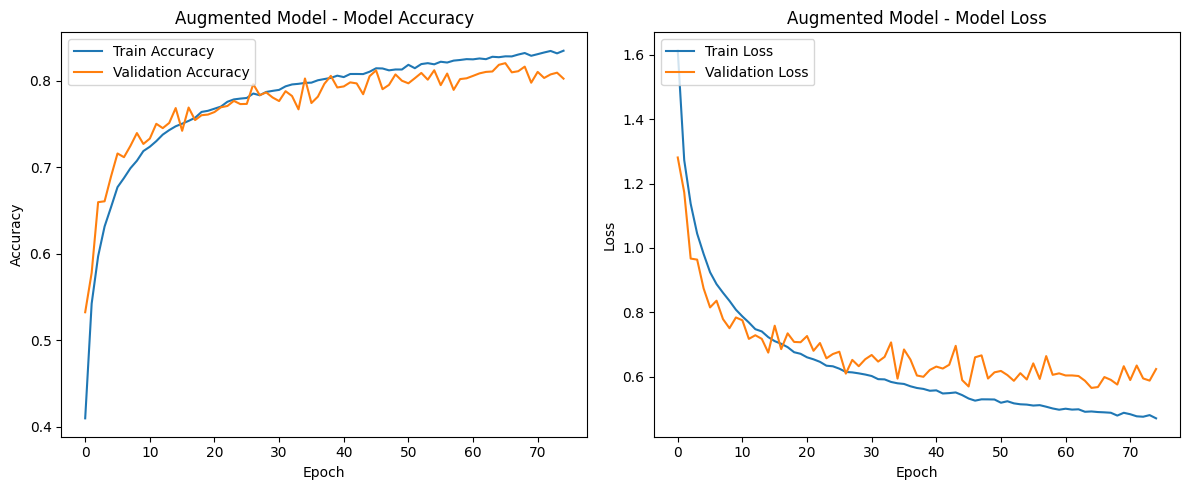

In [15]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# Plot for Non-Augmented Model
plot_history(non_aug_history, 'Non-Augmented Model')

# Plot for Augmented Model
plot_history(aug_history, 'Augmented Model')